# Phase 8 — Fine-tune and evaluate

The pretrained model knows English (perplexity 55 from a random 32,000). Now the 18,395 Shakespeare pairs only have to teach the style mapping.

**The question:** does it beat **19.22**, the copy baseline that Phase 4 scored 15.07 against?

In [1]:
import os, sys

for candidate in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.isdir(os.path.join(candidate, "src")):
        ROOT = candidate
        sys.path.insert(0, ROOT)
        break

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.config import TransformerConfig, get_device
from src.dataset import TranslationDataset, load_split, make_dataloader
from src.evaluate import bleu, copy_baseline
from src.inference import cross_attention_map, translate_corpus
from src.spm_tokenizer import SPMTokenizer
from src.train import fit, load_checkpoint, load_pretrained, overfit_batch
from src.transformer import build_model

%matplotlib inline
DATA = os.path.join(ROOT, "data")
PRETRAINED = os.path.join(ROOT, "checkpoints", "pretrained.pt")
FINETUNED = os.path.join(ROOT, "checkpoints", "finetuned.pt")

device = get_device()
torch.manual_seed(0)

tokenizer = SPMTokenizer(os.path.join(DATA, "spm32k.model"))
train_src, train_tgt = load_split(DATA, "train")
valid_src, valid_tgt = load_split(DATA, "valid")
test_src, test_tgt = load_split(DATA, "test")

valid_baseline = copy_baseline(valid_src, valid_tgt)
test_baseline = copy_baseline(test_src, test_tgt)

print("device:", device, "| vocab:", len(tokenizer))
print(f"copy baseline   valid {valid_baseline:.2f}   test {test_baseline:.2f}")

device: cuda | vocab: 32000
copy baseline   valid 15.97   test 19.22


## 1. Load the pretrained weights

Config comes from the checkpoint, so the architecture matches exactly.

Two knobs against overfitting — the first Phase 8 run hit a **31-point** train/valid accuracy gap (81.5% vs 50.6%) with validation loss rising from epoch 2:

- **`DROPOUT`** — 0.3 instead of 0.2.
- **`FREEZE_ENCODER_LAYERS`** — how many of the 6 encoder layers to freeze, counting from the bottom. Lower layers learn general lexical and syntactic features that transfer well; upper layers are more task-specific and benefit from adapting. `3` is the usual starting point; `0` is full fine-tuning, `6` freezes the whole encoder.

Two things deliberately stay trainable. The **decoder**, always — its job changed completely between pretraining (short sentinel-delimited fragments) and now (fluent sentences), and it is where the repetition loops come from. And the **embedding**, because `src_embed.weight` is tied to `generator.weight`; freezing it would also freeze the output projection and stop the model learning the target distribution.

In [2]:
DROPOUT = 0.3
FREEZE_ENCODER_LAYERS = 3      # 0 = none, 6 = whole encoder

checkpoint = torch.load(PRETRAINED, map_location="cpu", weights_only=False)
print("pretrained for", f"{checkpoint['step']:,}", "steps")

config = TransformerConfig(**checkpoint["config"])
config.dropout = DROPOUT

model = build_model(config).to(device)
load_pretrained(model, PRETRAINED, device)

for i, layer in enumerate(model.encoder.layers):
    if i < FREEZE_ENCODER_LAYERS:
        for p in layer.parameters():
            p.requires_grad = False

# embedding is tied to the output projection - it must stay trainable
model.src_embed.weight.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total = trainable + frozen

print(f"
dropout {DROPOUT} | frozen encoder layers "
      f"{FREEZE_ENCODER_LAYERS}/{len(model.encoder.layers)}")
for i, layer in enumerate(model.encoder.layers):
    state = "frozen " if not layer.self_attn.W_q.weight.requires_grad else "training"
    print(f"  encoder.{i}  {state}")
print(f"
  trainable {trainable:>12,}  ({trainable/total:.0%})")
print(f"  frozen    {frozen:>12,}")

pretrained for 33,228 steps
config: {'vocab_size': 32000, 'd_model': 384, 'num_heads': 8, 'num_layers': 6, 'd_ff': 1536, 'dropout': 0.1, 'max_len': 512, 'pad_idx': 0}

loaded 37,108,224 params


Before training, check the embeddings actually learned meaning. `thou` should sit near `you`/`thee`, `hath` near `has`. This is the clearest evidence pretraining did something — and it is exactly what a word2vec nearest-neighbour check would show, except these came out of the transformer.

In [3]:
import torch.nn.functional as F

embed = model.src_embed.weight.detach()

def neighbours(word, k=6):
    ids = tokenizer.encode(word)
    if len(ids) != 1:
        return f"{word} -> not a single token"
    v = embed[ids[0]]
    sim = F.cosine_similarity(v.unsqueeze(0), embed, dim=-1)
    top = sim.topk(k + 1).indices.tolist()[1:]
    return f"{word:<10} -> " + ", ".join(tokenizer.sp.id_to_piece(i) for i in top)

for w in ["thou", "hath", "thy", "king", "love", "sword"]:
    print(neighbours(w))

thou       -> ▁Thou, ▁ye, ▁thine, ▁hast, Thou, ▁thyself
hath       -> ▁doth, ▁hast, ▁takes, ▁gives, ▁finds, ▁gets
thy        -> ▁thine, ▁thee, ▁Thy, ▁Your, ▁thou, ▁Our
king       -> ▁prince, ▁priest, ▁queen, ▁Prince, ▁King, ▁knight
love       -> ▁pity, ▁fear, ▁desire, ▁hate, ▁loved, ▁honour
sword      -> ▁spear, ▁shield, ▁knife, ▁bow, ▁lion, ▁rope


## 2. Data

Same corpus and the same by-play split as Phase 3 — 15 plays train, *Twelfth Night* valid, *Romeo and Juliet* test. The only change is the tokenizer: subwords instead of the 10,119-word vocabulary.

Because SentencePiece round-trips the corpus tokenisation exactly (0 failures / 8,924), the 19.22 baseline stays directly comparable to Phase 4.

In [4]:
BATCH = 32

train_loader = make_dataloader(TranslationDataset(train_src, train_tgt, tokenizer), batch_size=BATCH)
valid_loader = make_dataloader(TranslationDataset(valid_src, valid_tgt, tokenizer),
                               batch_size=BATCH, shuffle=False)

src, tgt_in, tgt_out = next(iter(train_loader))
print("src   ", tuple(src.shape), "|", tokenizer.decode(src[0]))
print("target", tuple(tgt_out.shape), "|", tokenizer.decode(tgt_out[0]))

src    (32, 10) | How came these things to pass ?
target (32, 17) | How did this happen ?


## 3. Gate — overfit one batch

Same check as every phase. Fast here, because a pretrained model memorises easily.

In [5]:
probe_config = TransformerConfig(**checkpoint["config"])
probe_config.dropout = 0.0
probe = build_model(probe_config).to(device)
load_pretrained(probe, PRETRAINED, device)

batch = tuple(t.to(device) for t in next(iter(train_loader)))
h = overfit_batch(probe, batch, steps=200, log_every=100)
print(f"\nloss {h['loss'][0]:.3f} -> {h['loss'][-1]:.4f}   acc {h['acc'][-1]:.1%}")

del probe
torch.cuda.empty_cache()

step     1   loss 8.2932   acc  6.0%
step   100   loss 0.0075   acc 100.0%
step   200   loss 0.0024   acc 100.0%

loss 8.293 -> 0.0024   acc 100.0%


## 4. Fine-tune

Lower learning rate than pretraining — the weights are already good and a large step would destroy them. Selection is on validation BLEU, not loss.

In [6]:
torch.manual_seed(0)

history = fit(
    model, config, train_loader, valid_loader,
    valid_src, valid_tgt, tokenizer, device,
    epochs=30, patience=8, lr=5e-4, warmup=400,
    label_smoothing=0.1, checkpoint_path=FINETUNED, baseline=valid_baseline,
)

epoch   1  train 4.884/35.5%  valid 4.419/41.8%  BLEU[greedy]   4.97 (baseline 15.97)  <- best
epoch   2  train 4.147/45.3%  valid 4.227/45.2%  BLEU[greedy]   7.08 (baseline 15.97)  <- best
epoch   3  train 3.899/49.0%  valid 4.156/46.9%  BLEU[greedy]   9.44 (baseline 15.97)  <- best
epoch   4  train 3.756/51.1%  valid 4.115/47.9%  BLEU[greedy]  10.11 (baseline 15.97)  <- best
epoch   5  train 3.642/53.0%  valid 4.087/48.6%  BLEU[greedy]  10.72 (baseline 15.97)  <- best
epoch   6  train 3.554/54.2%  valid 4.069/49.1%  BLEU[greedy]  11.09 (baseline 15.97)  <- best
epoch   7  train 3.477/55.6%  valid 4.058/49.5%  BLEU[greedy]  11.32 (baseline 15.97)  <- best
epoch   8  train 3.416/56.4%  valid 4.041/50.3%  BLEU[greedy]  12.15 (baseline 15.97)  <- best
epoch   9  train 3.360/57.3%  valid 4.030/50.2%  BLEU[greedy]  12.10 (baseline 15.97)
epoch  10  train 3.306/58.1%  valid 4.028/50.4%  BLEU[greedy]  12.40 (baseline 15.97)  <- best
epoch  11  train 3.257/59.0%  valid 4.025/50.7%  BLEU[greed

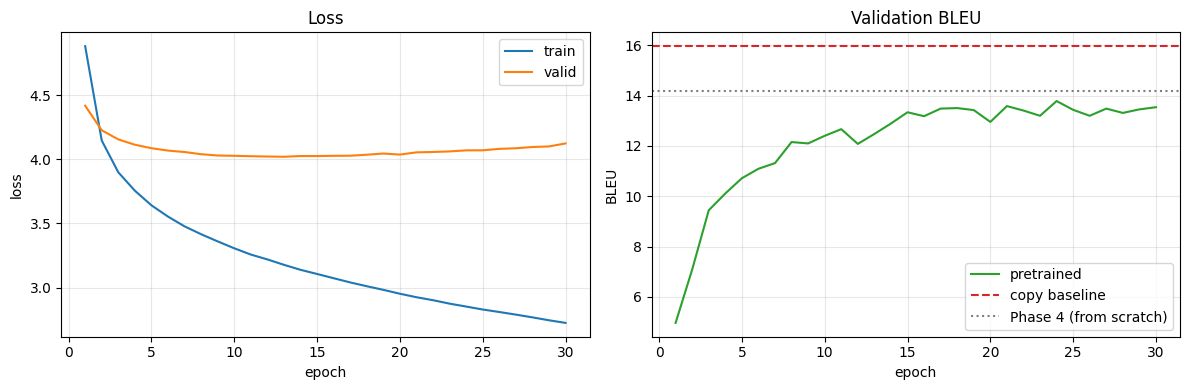

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["epoch"], history["train_loss"], label="train")
axes[0].plot(history["epoch"], history["valid_loss"], label="valid")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title("Loss")

axes[1].plot(history["epoch"], history["bleu"], color="tab:green", label="pretrained")
axes[1].axhline(valid_baseline, color="tab:red", ls="--", label="copy baseline")
axes[1].axhline(14.20, color="tab:gray", ls=":", label="Phase 4 (from scratch)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("BLEU")
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_title("Validation BLEU")

plt.tight_layout(); plt.show()

## 5. Tune decoding on validation

Beam size and length penalty are chosen here, then applied **once** to test. Phase 4 measured α≈1.5 as best, not the textbook 0.6 — worth re-checking, since this model may not under-generate the same way.

In [8]:
best, meta = load_checkpoint(FINETUNED, device=device)
print(f"best epoch {meta['epoch']}, valid BLEU {meta['score']:.2f}\n")

print(f"{'setting':>16} {'BLEU':>7} {'avg len':>8}")
greedy = translate_corpus(best, valid_src, tokenizer, device, batch_size=64)
best_score, best_setting = bleu(greedy, valid_tgt), None
print(f"{'greedy':>16} {best_score:7.2f} {sum(len(l.split()) for l in greedy)/len(greedy):8.1f}")

for beam in (4, 5):
    for alpha in (0.6, 1.0, 1.5, 2.0):
        out = translate_corpus(best, valid_src, tokenizer, device, batch_size=32,
                               beam_size=beam, length_penalty=alpha)
        score = bleu(out, valid_tgt)
        print(f"{f'beam {beam} a={alpha}':>16} {score:7.2f} "
              f"{sum(len(l.split()) for l in out)/len(out):8.1f}")
        if score > best_score:
            best_score, best_setting = score, (beam, alpha)

print(f"\nbest on valid: {best_setting or 'greedy'}  ({best_score:.2f})")

best epoch 24, valid BLEU 13.78

         setting    BLEU  avg len
          greedy   13.79     10.1
    beam 4 a=0.6   14.14      8.8
    beam 4 a=1.0   14.35      9.0
    beam 4 a=1.5   14.69      9.9
    beam 4 a=2.0   13.94     10.6
    beam 5 a=0.6   13.98      8.6
    beam 5 a=1.0   14.30      8.9
    beam 5 a=1.5   14.68      9.8
    beam 5 a=2.0   13.95     10.6

best on valid: (4, 1.5)  (14.69)


## 6. Test — the answer

*Romeo and Juliet*, unseen. Scored once, with the same diagnostics Phase 4 recorded so the two are directly comparable.

In [9]:
if best_setting:
    beam, alpha = best_setting
    predictions = translate_corpus(best, test_src, tokenizer, device, batch_size=32,
                                   beam_size=beam, length_penalty=alpha)
    label = f"beam {beam}, a={alpha}"
else:
    predictions = translate_corpus(best, test_src, tokenizer, device, batch_size=64)
    label = "greedy"

test_bleu = bleu(predictions, test_tgt)

print(f"TEST BLEU        {test_bleu:6.2f}   ({label})")
print(f"copy baseline    {test_baseline:6.2f}")
print(f"Phase 4          {15.07:6.2f}   (from scratch, no pretraining)")
print()
print(f"vs baseline      {test_bleu - test_baseline:+6.2f}")
print(f"vs Phase 4       {test_bleu - 15.07:+6.2f}")
print()
print("VERDICT:", "BEATS THE COPY BASELINE" if test_bleu > test_baseline
      else "still below the copy baseline")

TEST BLEU         15.18   (beam 4, a=1.5)
copy baseline     19.22
Phase 4           15.07   (from scratch, no pretraining)

vs baseline       -4.04
vs Phase 4        +0.11

VERDICT: still below the copy baseline


### Diagnostics, against the Phase 4 numbers

In [10]:
def duplicate_rate(lines):
    dup = tot = 0
    for l in lines:
        w = l.split()
        dup += sum(a == b for a, b in zip(w, w[1:])); tot += max(len(w) - 1, 0)
    return dup / max(tot, 1)

def copy_rate(hyps, source):
    kept = tot = 0
    for h, s in zip(hyps, source):
        sw = set(s.split())
        for w in h.split():
            tot += 1; kept += w in sw
    return kept / max(tot, 1)

tokens_out = sum(len(p.split()) for p in predictions)
unk = sum(w == "<unk>" for p in predictions for w in p.split()) / max(tokens_out, 1)

print(f"{'metric':<26} {'Phase 4':>9} {'now':>9}")
print(f"{'test BLEU':<26} {15.07:>9.2f} {test_bleu:>9.2f}")
print(f"{'<unk> in output':<26} {'3.65%':>9} {unk:>8.2%}")
print(f"{'adjacent duplicates':<26} {'0.85%':>9} {duplicate_rate(predictions):>8.2%}")
print(f"{'copy rate (ref 54.3%)':<26} {'61.8%':>9} {copy_rate(predictions, test_src):>8.1%}")
print(f"{'length ratio':<26} {'1.02':>9} "
      f"{tokens_out/sum(len(r.split()) for r in test_tgt):>9.2f}")

print(f"\n{'source tokens':>14} {'n':>5} {'model':>7} {'copy':>7} {'Phase 4':>8}")
p4 = {"1-5": 25.84, "6-10": 18.87, "11-15": 17.94, "16-25": 10.32, "26+": 6.18}
for (lo, hi), key in zip([(1,5),(6,10),(11,15),(16,25),(26,10000)], p4):
    idx = [i for i, s in enumerate(test_src) if lo <= len(s.split()) <= hi]
    if len(idx) < 10:
        continue
    m = bleu([predictions[i] for i in idx], [test_tgt[i] for i in idx])
    c = bleu([test_src[i] for i in idx], [test_tgt[i] for i in idx])
    print(f"{key:>14} {len(idx):>5} {m:7.2f} {c:7.2f} {p4[key]:8.2f}")

metric                       Phase 4       now
test BLEU                      15.07     15.18
<unk> in output                3.65%    0.00%
adjacent duplicates            0.85%    0.09%
copy rate (ref 54.3%)          61.8%    57.9%
length ratio                    1.02      0.98

 source tokens     n   model    copy  Phase 4
           1-5   368   24.85   28.12    25.84
          6-10   550   19.32   24.33    18.87
         11-15   252   14.65   22.03    17.94
         16-25   200   12.05   15.44    10.32
           26+    92    7.29   10.11     6.18


In [11]:
for i in (3, 11, 25, 60):
    print("SHAKESPEARE:", test_src[i])
    print("MODEL      :", predictions[i])
    print("REFERENCE  :", test_tgt[i])
    print()

SHAKESPEARE: When and where and how We met , we wooed and made exchange of vow , I'll tell thee as we pass , but this I pray : That thou consent to marry us today .
MODEL      : When we met here and how we met you , we'll give you what I'll say , that you'll give us this to you today , tell us that I'll marry you today .
REFERENCE  : I'll tell you more later about when and where we met , how we fell in love , and how we exchanged promises , but now I'm begging you : please , agree to marry us today .

SHAKESPEARE: Pronounce this sentence then : Women may fall when there's no strength in men .
MODEL      : Then you can't be able to get married when there's no reason for men .
REFERENCE  : Then repeat this after me : you can't expect women to be faithful when men are so unreliable .

SHAKESPEARE: Came he not home tonight ?
MODEL      : Didn't he come home tonight ?
REFERENCE  : Didn't he come home last night ?

SHAKESPEARE: Thy wit is a very bitter sweeting .
MODEL      : Your wit is a v

## 7. Attention

The same `(batch, heads, tgt_len, src_len)` tensor that produced the diagonal on the toy copy task in `01_toy_copy_task.ipynb` — now on a real sentence, showing which source word each generated word attended to.

This is the mechanism from *Attention Is All You Need*, in your own code, doing the actual work.

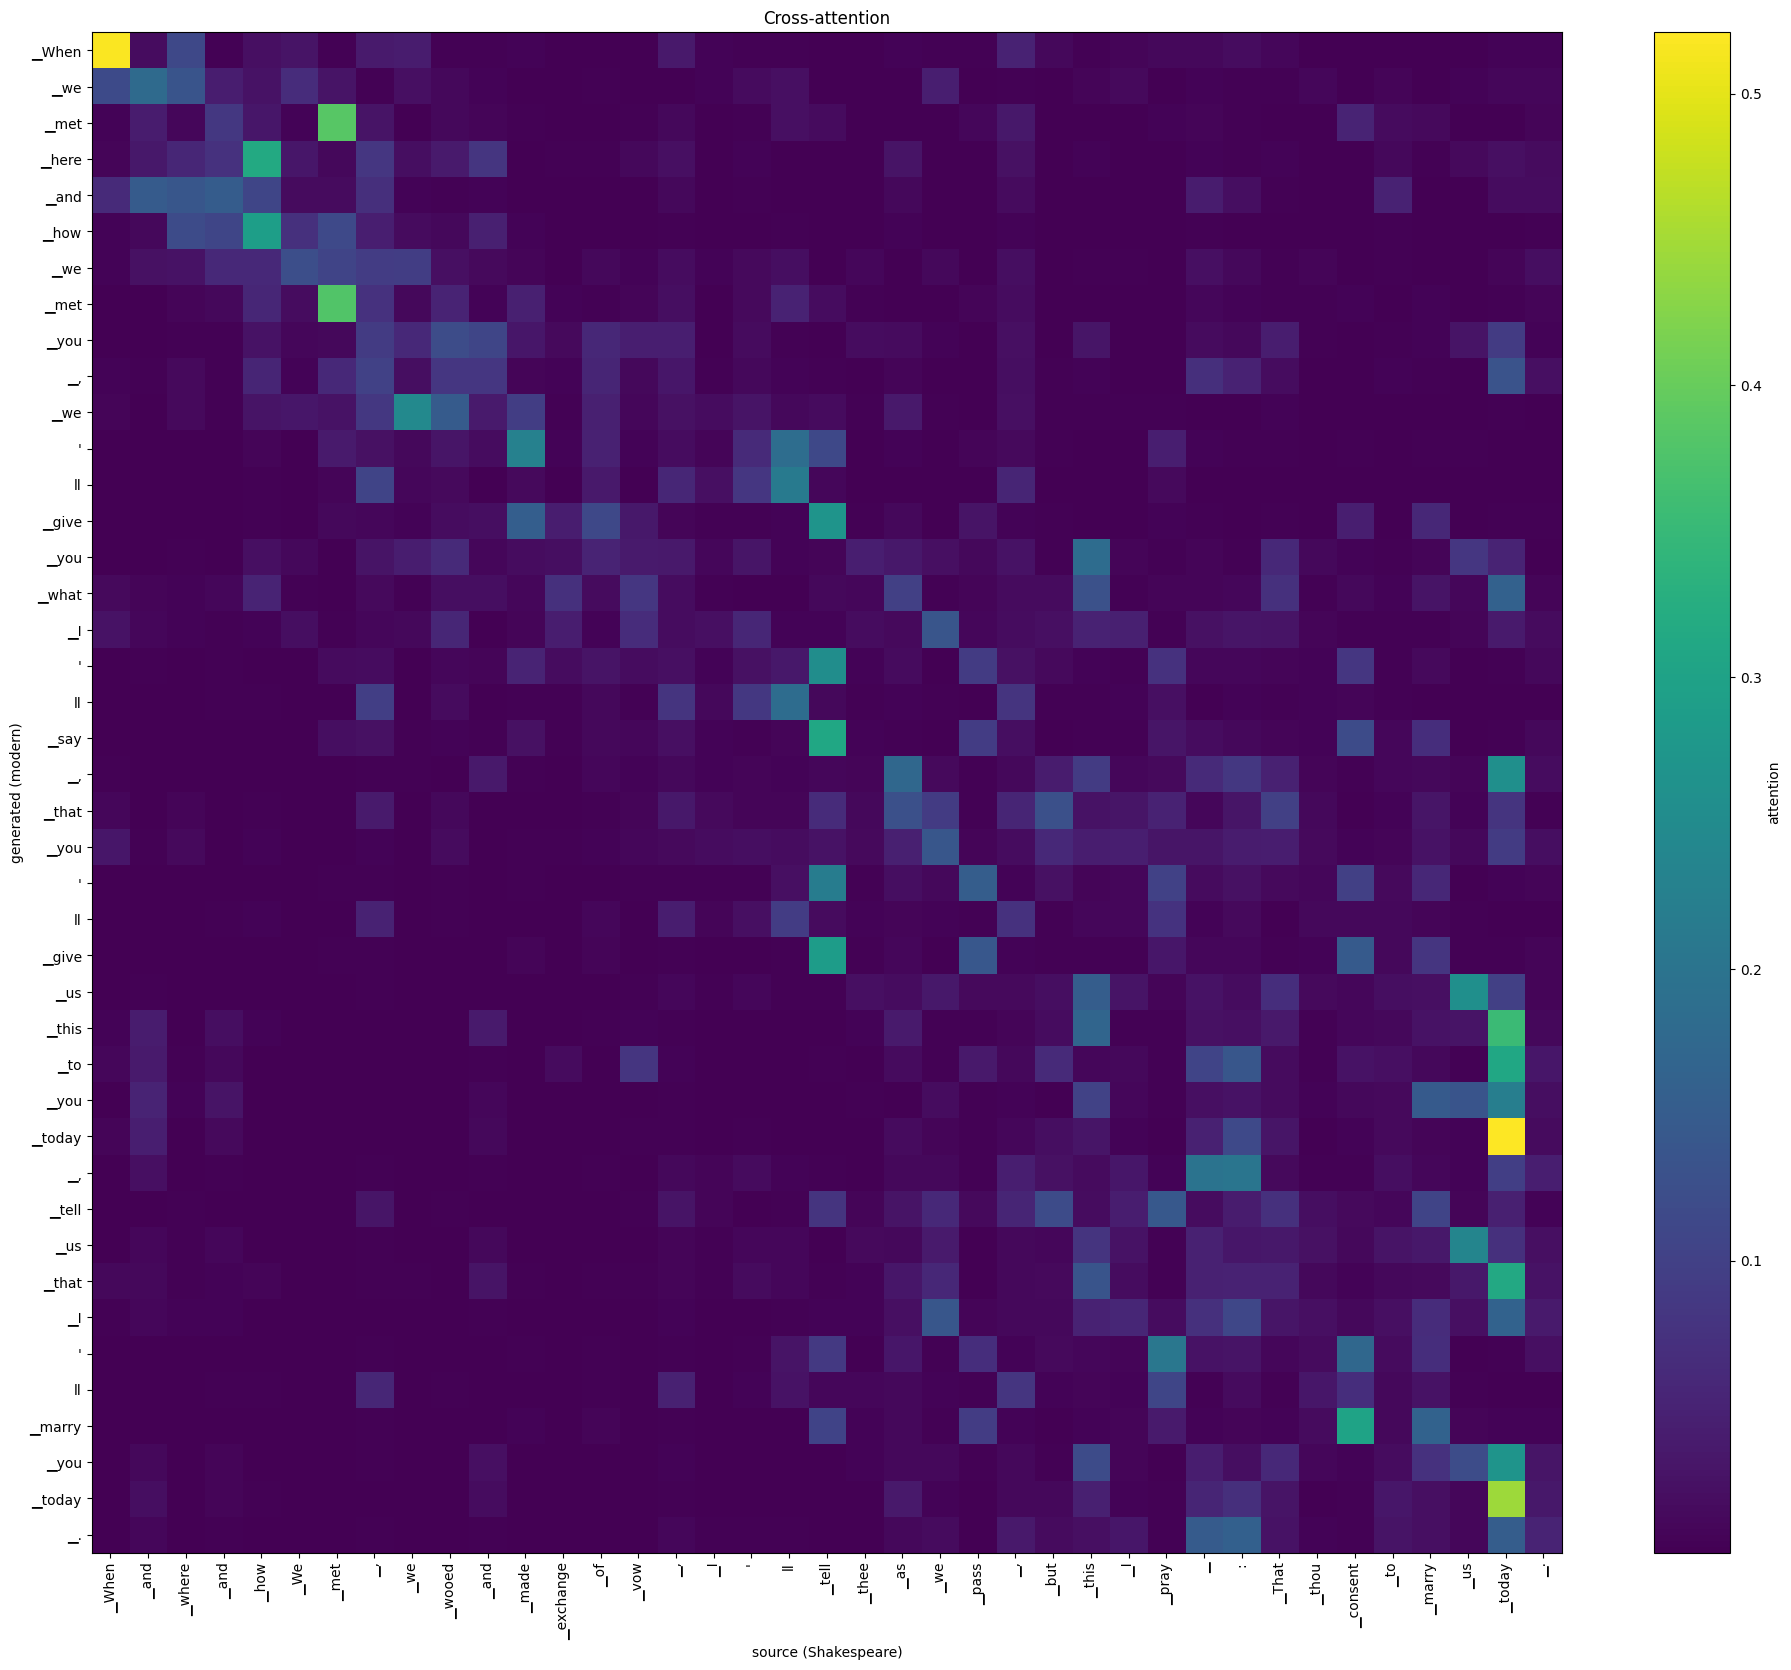

In [12]:
i = 3
src_ids = torch.tensor([tokenizer.encode(test_src[i]) + [2]], device=device)
tgt_ids = torch.tensor([[1] + tokenizer.encode(predictions[i])], device=device)

attn = cross_attention_map(best, src_ids, tgt_ids)[0].cpu()
src_pieces = tokenizer.sp.encode(test_src[i], out_type=str)
tgt_pieces = tokenizer.sp.encode(predictions[i], out_type=str)

n_t, n_s = min(len(tgt_pieces), attn.size(0)), min(len(src_pieces), attn.size(1))

plt.figure(figsize=(max(8, n_s * 0.5), max(5, n_t * 0.4)))
plt.imshow(attn[:n_t, :n_s].numpy(), cmap="viridis", aspect="auto")
plt.colorbar(label="attention")
plt.xticks(range(n_s), src_pieces[:n_s], rotation=90)
plt.yticks(range(n_t), tgt_pieces[:n_t])
plt.xlabel("source (Shakespeare)"); plt.ylabel("generated (modern)")
plt.title("Cross-attention")
plt.tight_layout(); plt.show()

## Done

Whatever the number, it is now measured against the same baseline and the same diagnostics as Phase 4 — so the comparison means something.

If it clears 19.22: Phase 9, the book pipeline.
If not: the pretraining loss was still falling at step 33,228, so more corpus is the lever, not architecture.